# Import libraries 

In [120]:
import os
import numpy as np 
import pandas as pd# 

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from scipy import stats
from scipy.stats import shapiro
from scipy.stats import chi2_contingency, norm
import statsmodels.api as sm
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import warnings
warnings.filterwarnings('ignore')

# Part 1: Regression Model

# Import Data

In [121]:
df1=pd.read_csv("Credit_risk_dataset.csv") #for regression

# EDA (Exploratory Data Analysis)

In [125]:
# shape of data
df1.shape

(32581, 12)

In [126]:
# Brows Data Portion
# Head of data
df1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [127]:
# tail of data
df1.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [128]:
#head and tail
df1

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


### Loan interest rate is the target

In [129]:
# Brows discriptor portion
##checking  number of obs and columns ,index of columns, name of columns, number of non_null values and datatype, (memory usage,...)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [132]:
# convert loan_status data type
df1['loan_status']=df1['loan_status'].astype("object")

In [133]:
# find number of missing values
df1.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [97]:
def inforamation(df):
    df_information= pd.concat([df1.dtypes, df.isna().sum(),df.nunique()], axis=1, keys=['Data types','Number of Missing', 'Number of uique values'])
    return(df_information)

In [98]:
inforamation(df1)

,Data types,Number of Missing,Number of uique values
person_age,int64,0,58
person_income,int64,0,4295
person_home_ownership,object,0,4
person_emp_length,float64,895,36
loan_intent,object,0,6
loan_grade,object,0,7
loan_amnt,int64,0,753
loan_int_rate,float64,3116,348
loan_status,int64,0,2
loan_percent_income,float64,0,77


## Descrptive Statistic

In [135]:
# get the summary of Data
# for only numeric columns
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [136]:
# for all columns
df1.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.0,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,2.0,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,0.0,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,25473.0,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,NaN,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,NaN,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,NaN,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,NaN,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,NaN,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,NaN,0.230000,NaN,8.000000


In [137]:
# To get mode( top) and number of levels for all columns
df1.astype('object').describe().T

,count,unique,top,freq
person_age,32581,58,23,3889
person_income,32581,4295,60000,1046
person_home_ownership,32581,4,RENT,16446
person_emp_length,31686.0,36.0,0.0,4105.0
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
loan_amnt,32581,753,10000,2664
loan_int_rate,29465.0,348.0,7.51,756.0
loan_status,32581,2,0,25473
loan_percent_income,32581.0,77.0,0.1,1533.0


# Data Prepration

## Data Cleansing
1. Handling Duplicate Data
2. Handling Missing Values
3. Handling Outliers
4. Standardising Values
5. Fixing Invalid Values and Filter Data

### 1. Handling Duplicate Data

In [138]:
# Find number of duplicated rows
df1.duplicated().sum()

np.int64(165)

In [139]:
# Get a copy of data
df_original=df1.copy()

In [140]:
df_1=df1.drop_duplicates()
df1.shape, df_1.shape, df1.shape[0]-df_1.shape[0]

((32581, 12), (32416, 12), 165)

In [141]:
df1=df_1.copy()# copy by value

### 2. Handling Missing Values

In [142]:
df1.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [150]:
#calculatin no. of missing values for each column and it's percentage
def percentage_of_miss(df):
  df=df1[df1.columns[df.isnull().sum()>=1]]
  total_miss = df.isnull().sum().sort_values(ascending=False)
  percent_miss = (df.isnull().sum()/df1.shape[0]).sort_values(ascending=False)
  missing_data = pd.concat([total_miss, percent_miss], axis=1, keys=['Number of Missing', 'Percentage of Missing'])
  return(missing_data)

In [151]:
percentage_of_miss(df1)

,Number of Missing,Percentage of Missing


In [145]:
# drop rows that have missing for all columns
df1.dropna(how='all',inplace =True)

In [146]:
percentage_of_miss(df1)

,Number of Missing,Percentage of Missing
loan_int_rate,3095,0.095478
person_emp_length,887,0.027363


In [152]:
#since the number of observation for the missing value compared to the dataset  is too small ,I will remove those observation
df1.dropna(subset=['loan_int_rate','person_emp_length'],inplace=True)

In [153]:
df1.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [154]:
print("Shape of data after droping missing values:",df1.shape)

Shape of data after droping missing values: (28501, 12)


 ## UNIVARIATE ANALYSIS

In [155]:
# get all categorical columns:
df_cat=df1.select_dtypes(include='object')
df_cat.columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade', 'loan_status',
       'cb_person_default_on_file'],
      dtype='object')

In [156]:
# get all numerical columns:
df_num=df1.select_dtypes(exclude='object')
df_num.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

In [157]:
# Find the frequency of each levels in all categorcal columns
for c in df_cat.columns:
    print(df1[c].value_counts()) 

person_home_ownership
RENT        14498
MORTGAGE    11736
OWN          2174
OTHER          93
Name: count, dtype: int64
loan_intent
EDUCATION            5670
MEDICAL              5269
VENTURE              4969
PERSONAL             4859
DEBTCONSOLIDATION    4547
HOMEIMPROVEMENT      3187
Name: count, dtype: int64
loan_grade
A    9345
B    9094
C    5682
D    3243
E     869
F     209
G      59
Name: count, dtype: int64
loan_status
0    22313
1     6188
Name: count, dtype: int64
cb_person_default_on_file
N    23411
Y     5090
Name: count, dtype: int64


### Visualization

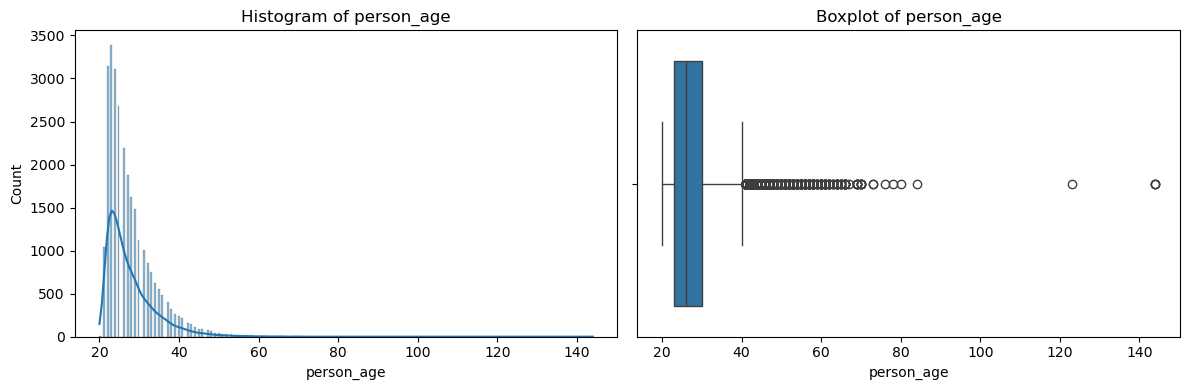

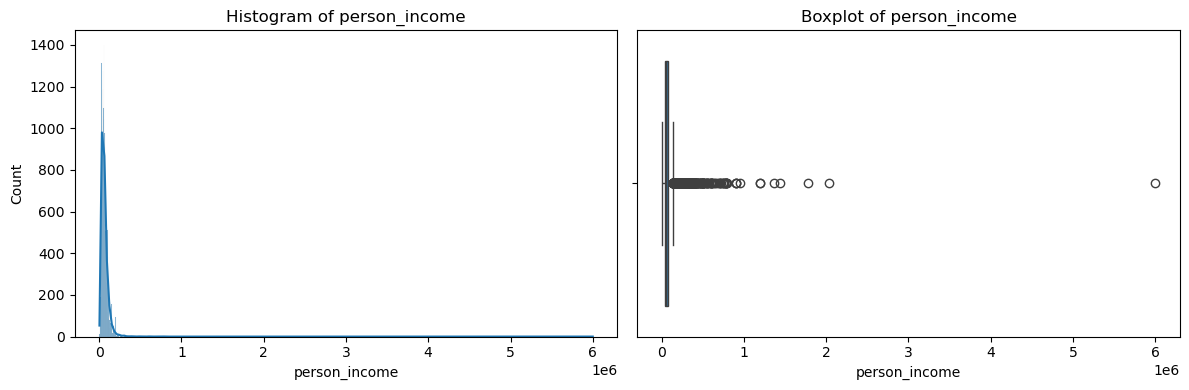

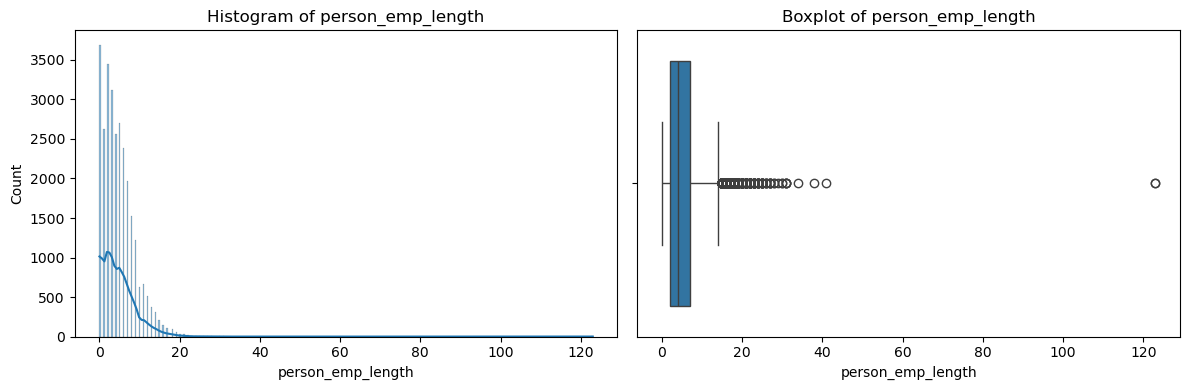

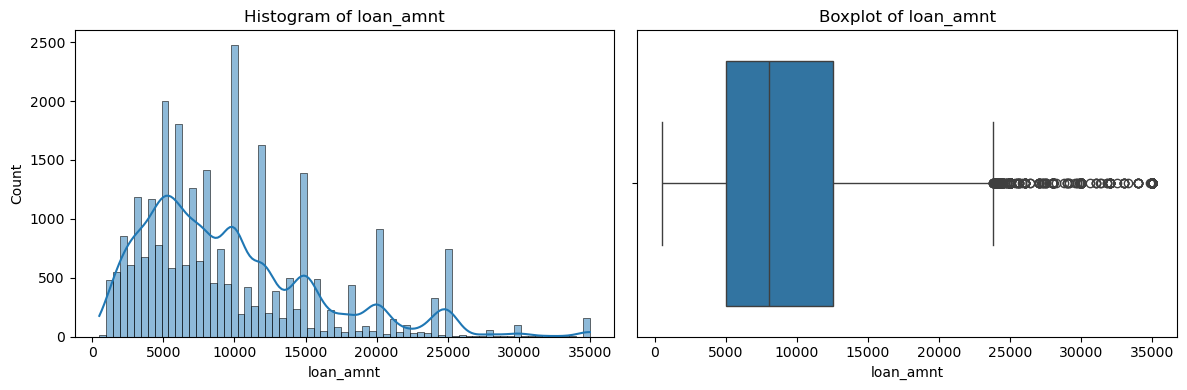

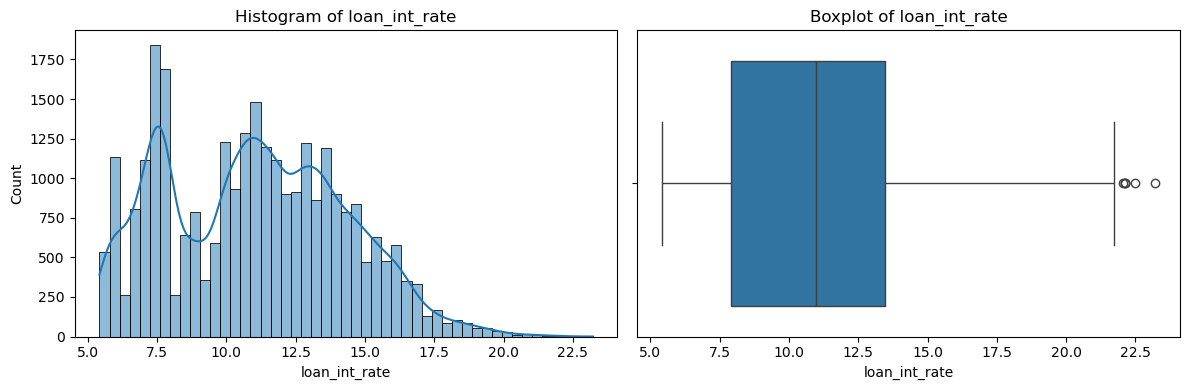

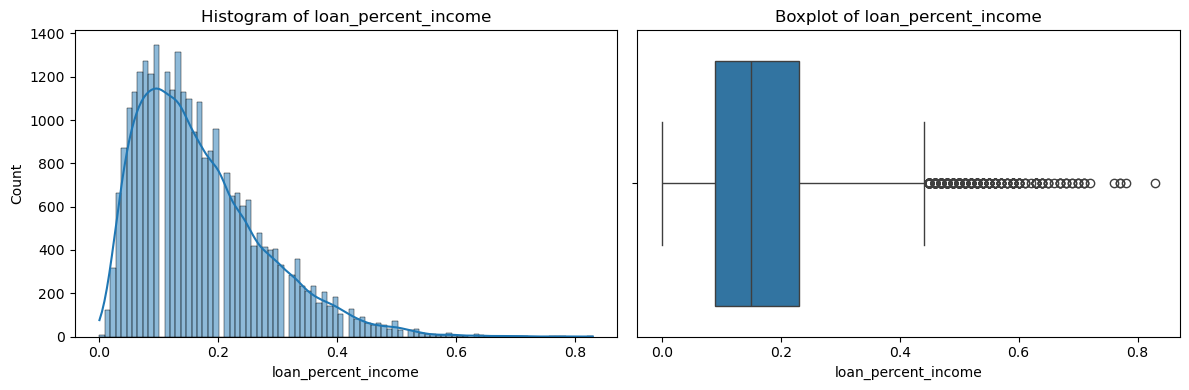

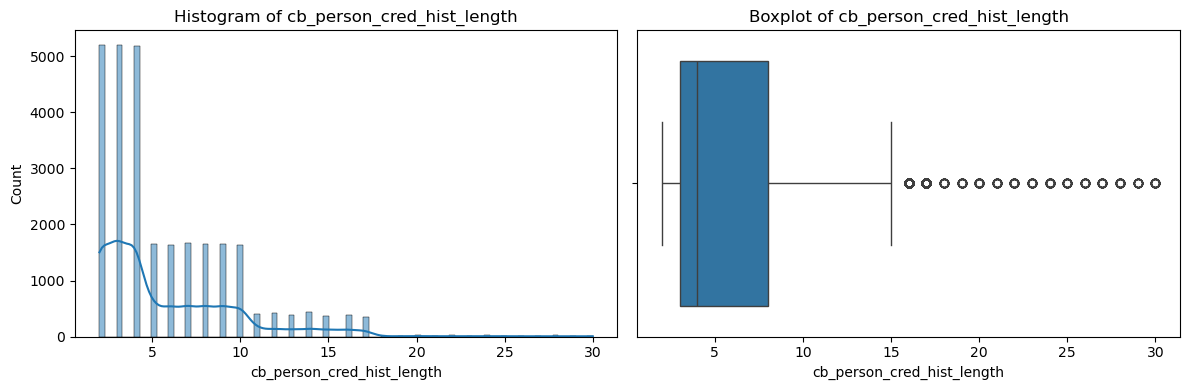

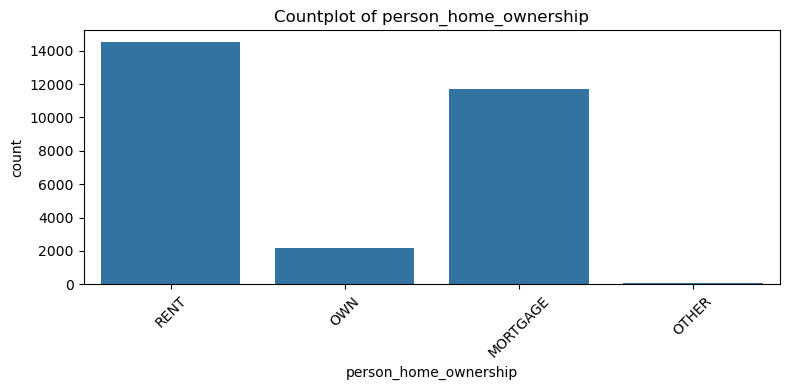

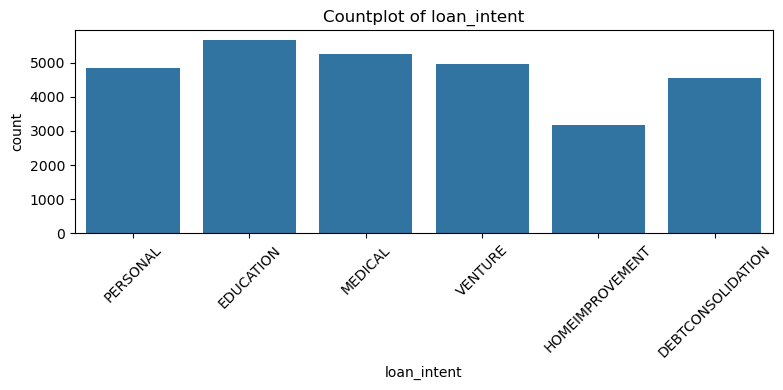

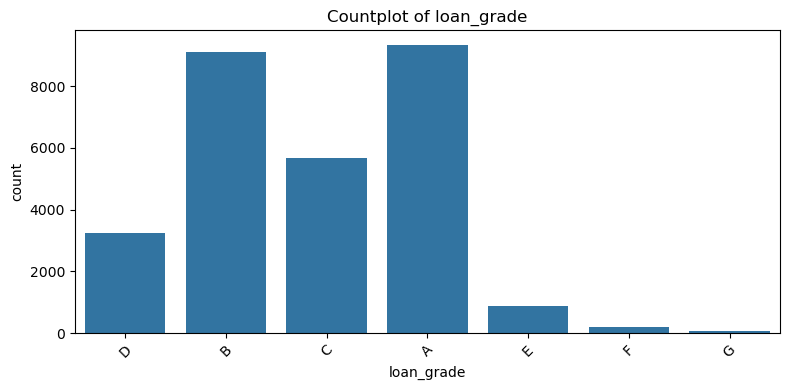

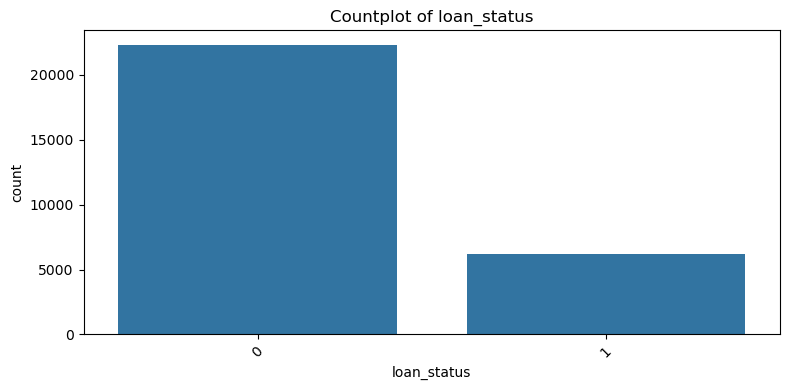

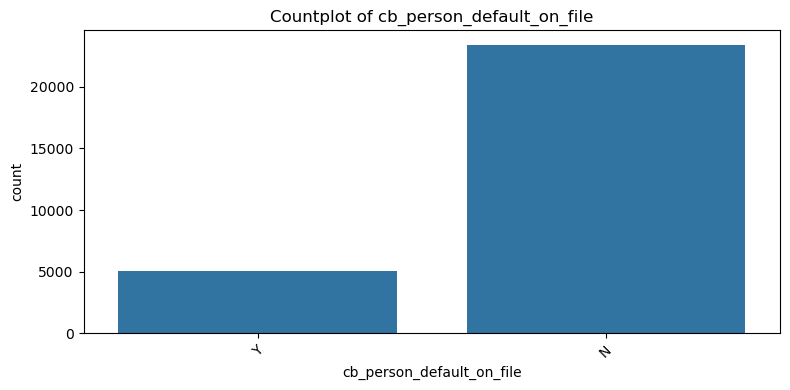

In [158]:
# --- Numeric variables: histograms & boxplots ---
for col in df_num.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df1[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {col}")
    
    # Boxplot
    sns.boxplot(x=df1[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()

# --- Categorical variables: countplots ---
for col in  df_cat.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df1, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [159]:
#summary of numeric
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,28501.0,27.738676,6.316166,20.00,23.00,26.00,30.00,144.00
person_income,28501.0,66654.411319,62376.028215,4000.00,39500.00,56000.00,80000.00,6000000.00
person_emp_length,28501.0,4.790148,4.157462,0.00,2.00,4.00,7.00,123.00
loan_amnt,28501.0,9658.533034,6329.604672,500.00,5000.00,8000.00,12500.00,35000.00
loan_int_rate,28501.0,11.045385,3.230748,5.42,7.90,10.99,13.48,23.22
loan_percent_income,28501.0,0.169517,0.106410,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,28501.0,5.800498,4.042153,2.00,3.00,4.00,8.00,30.00


In [160]:
df1.loan_int_rate.describe()

count    28501.000000
mean        11.045385
std          3.230748
min          5.420000
25%          7.900000
50%         10.990000
75%         13.480000
max         23.220000
Name: loan_int_rate, dtype: float64

In [161]:
df1.loan_int_rate.quantile([0,0.01,0.50,0.70,0.90,0.95,0.99,1]) 

0.00     5.42
0.01     5.42
0.50    10.99
0.70    12.98
0.90    15.31
0.95    16.32
0.99    18.62
1.00    23.22
Name: loan_int_rate, dtype: float64

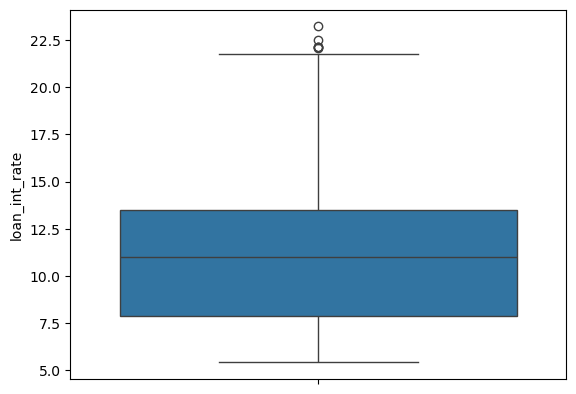

In [162]:
sns.boxplot( y=df1['loan_int_rate'] )
plt.show()

### 3 Detecting outliers

In [163]:
def outlier_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    count = outliers.shape[0]

    print(f"Lower bound: {lower}")
    print(f"Upper bound: {upper}")
    print(f"Outliers detected in '{column}': {count}")

    return outliers

In [164]:
# check outliers for person_age
result_age = outlier_iqr(df1, "person_age")

Lower bound: 12.5
Upper bound: 40.5
Outliers detected in 'person_age': 1296


In [175]:
df1.person_age.describe()

count    28501.000000
mean        27.738676
std          6.316166
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [165]:
df1[df1.person_age>80]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,0,0.11,N,24


The outlier detection function based on the IQR method did not correctly identify outliers in the person_age variable due to the highly skewed distribution of the data. The summary statistics indicate that 75% of the observations fall below 30 years of age, which results in a very narrow interquartile range. Because of this, the upper IQR bound was calculated at approximately 40, causing valid ages above 40 to be incorrectly flagged as potential outliers. However, the descriptive statistics show that the minimum age is 20 and the maximum age is 144, with only five observations above 80. These values are not necessarily erroneous, but they are extreme relative to the rest of the dataset. Therefore, the lack of detection from the initial function is a direct result of the distribution shape, rather than the absence of genuine extreme values.

In [166]:
df1 = df1[df1["person_age"] <= 100]
df1

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [167]:
df1.shape

(28497, 12)

In [187]:
# check outliers for person_income
result_age = outlier_iqr(df1, "person_income")

Lower bound: -21300.0
Upper bound: 140780.0
Outliers detected in 'person_income': 1321


In [191]:
type(df1)

pandas.core.frame.DataFrame

In [194]:
df1['person_income'].describe()

count    2.849700e+04
mean     6.643462e+04
std      5.151732e+04
min      4.000000e+03
25%      3.948000e+04
50%      5.600000e+04
75%      8.000000e+04
max      2.039784e+06
Name: person_income, dtype: float64

In [193]:
df1["person_income"].quantile([0.01, 0.50, 0.90, 0.95, 0.99])

0.01     14400.0
0.50     56000.0
0.90    112000.0
0.95    140000.0
0.99    230000.0
Name: person_income, dtype: float64

The personal income variable exhibits a strongly right-skewed distribution, with percentile values ranging from 14,400 at the 1st percentile to 230,000 at the 99th percentile. Because of this skewness, the IQR method produced an unrealistically low upper bound that incorrectly flagged over one thousand observations as outliers. Since high-income values are legitimate but rare in credit datasets, a percentile-based approach was adopted instead. Incomes were capped at the 99th percentile (230,000) to limit the influence of extreme values such as the maximum observed income of $2,000,000.  A logarithmic transformation was then applied to further normalize the distribution and ensure stable behavior in the loan interest rate regression model.

In [195]:
#Correct Outlier Treatment for Income 
#Step 1 — Cap income at the 99th percentile = 230,000
upper_cap = 230000  # or df1["person_income"].quantile(0.99)
df1["person_income_capped"] = df1["person_income"].clip(upper=upper_cap)

In [196]:
df1["person_income_log"] = np.log(df1["person_income_capped"] + 1)

In [198]:
df1[df1['person_income']>230000]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_income_capped,person_income_log
15,23,500000,MORTGAGE,7.0,DEBTCONSOLIDATION,B,30000,10.65,0,0.06,N,3,230000,12.345839
33,25,306000,RENT,2.0,DEBTCONSOLIDATION,C,24250,13.85,0,0.08,N,3,230000,12.345839
34,26,300000,MORTGAGE,10.0,MEDICAL,C,7800,13.49,0,0.03,N,4,230000,12.345839
42,26,300000,MORTGAGE,10.0,VENTURE,A,20000,7.88,0,0.07,N,4,230000,12.345839
43,23,300000,OWN,1.0,EDUCATION,F,24250,19.41,0,0.08,Y,2,230000,12.345839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32308,51,260000,MORTGAGE,1.0,PERSONAL,A,14000,7.66,0,0.05,N,26,230000,12.345839
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0,0.01,N,30,230000,12.345839
32543,52,720000,MORTGAGE,1.0,PERSONAL,A,7925,8.94,0,0.01,N,30,230000,12.345839
32544,58,780000,MORTGAGE,7.0,PERSONAL,A,4500,6.91,0,0.01,N,20,230000,12.345839


In [202]:
# check outliers for employment length
result_age = outlier_iqr(df1, "person_emp_length")

Lower bound: -5.5
Upper bound: 14.5
Outliers detected in 'person_emp_length': 772


In [204]:
df1.person_emp_length.describe()

count    28497.000000
mean         4.790048
std          4.157496
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [205]:
df1["person_emp_length"].quantile([0.01, 0.50, 0.90, 0.95, 0.99])

0.01     0.0
0.50     4.0
0.90    10.0
0.95    13.0
0.99    18.0
Name: person_emp_length, dtype: float64

The macimum age shown as 123 is unrealistic which might be due to data entry error


In [168]:
df1[df1["person_emp_length"]>30]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4
30914,48,70000,MORTGAGE,31.0,HOMEIMPROVEMENT,D,9000,14.54,0,0.13,N,17
31866,47,178000,OWN,31.0,VENTURE,B,9000,10.99,0,0.05,N,17
31867,46,180000,MORTGAGE,31.0,VENTURE,B,18000,9.91,0,0.10,N,11
32263,46,180000,MORTGAGE,31.0,MEDICAL,B,18000,9.91,0,0.10,N,12
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25
32428,58,49000,MORTGAGE,34.0,MEDICAL,D,7500,13.55,1,0.15,Y,24
32515,53,106000,MORTGAGE,38.0,PERSONAL,B,20000,9.88,0,0.19,N,23


There are 2 observation of 123 employment length which is unrealistic and should be dropped

In [169]:
df1 = df1[df1["person_emp_length"] <= 41]

In [170]:
df1.shape

(28495, 12)

In [49]:
# check outliers for loan percent income
result_age = outlier_iqr(df1, "loan_percent_income")

Lower bound: -0.12000000000000002
Upper bound: 0.44000000000000006
Outliers detected in 'loan_percent_income': 556


In [50]:
df1["loan_percent_income"].quantile([0.01, 0.50, 0.90, 0.95, 0.99])

0.01    0.02
0.50    0.15
0.90    0.32
0.95    0.38
0.99    0.50
Name: loan_percent_income, dtype: float64

In [31]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28501 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  28501 non-null  int64  
 1   person_income               28501 non-null  int64  
 2   person_home_ownership       28501 non-null  object 
 3   person_emp_length           28501 non-null  float64
 4   loan_intent                 28501 non-null  object 
 5   loan_grade                  28501 non-null  object 
 6   loan_amnt                   28501 non-null  int64  
 7   loan_int_rate               28501 non-null  float64
 8   loan_status                 28501 non-null  object 
 9   loan_percent_income         28501 non-null  float64
 10  cb_person_default_on_file   28501 non-null  object 
 11  cb_person_cred_hist_length  28501 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 2.8+ MB


In [54]:
df1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Bivariate Analysis

### 1: Chi Square Test

#### Person_home_ownership vs Loan Status

**Categorical vs. Categorical**

**Summarization:**
Contingency Table (two-way frequency table)

**Visualization:**
Stacked Bar Chart

 Grouped Bar Chart

**Statistical Test:**
Chi-Square Test of Independence

**H0 (Null Hypothesis):**

There is no association between two Variables(They are statistically independent.)

**H1 (Alternative Hypothesis):**

There is an association between the Variables((They are not independent.)

In [35]:
df1.person_home_ownership.value_counts()

person_home_ownership
RENT        14498
MORTGAGE    11736
OWN          2174
OTHER          93
Name: count, dtype: int64

In [36]:
df1.loan_status.value_counts()

loan_status
0    22313
1     6188
Name: count, dtype: int64

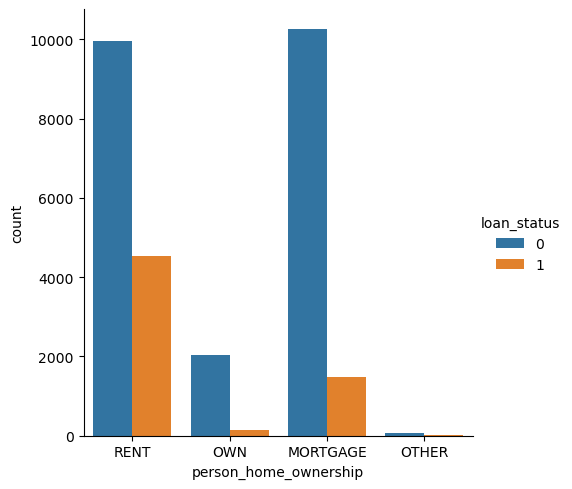

In [38]:
sns.catplot(x='person_home_ownership', kind="count",hue = 'loan_status', data=df1)
plt.show()

In [44]:
contingency_table1 = pd.crosstab(df1['person_home_ownership'],df1['loan_status'])
contingency_table1

loan_status,0,1
person_home_ownership,,
MORTGAGE,10253,1483
OTHER,66,27
OWN,2029,145
RENT,9965,4533


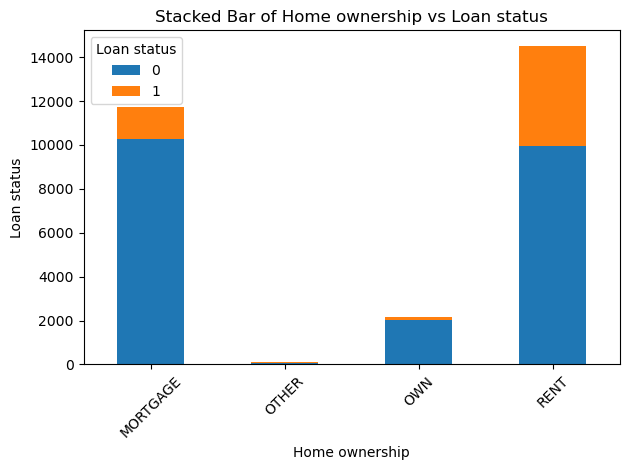

In [45]:
# Visualization Stacked bar
contingency_table1.plot(kind='bar', stacked=True)

plt.title(f"Stacked Bar of Home ownership vs Loan status")
plt.xlabel('Home ownership')
plt.ylabel("Loan status")
plt.xticks(rotation=45)
plt.legend(title='Loan status', loc='upper left')
plt.tight_layout()
plt.show()

In [48]:
chi2, p, dof, expected = chi2_contingency(contingency_table1)

print("\nChi-square test:  Home ownership vs Loan status")
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)

print("\np-value:", p)
if p < 0.05:
    print('**There is statistiacally significant correlation between Homeownership and Loan status at 0.05 significant level**')
else:
    print("***There is no association between the two variables***")


Chi-square test:  Home ownership vs Loan status
Chi-square statistic: 1639.6586711937
Degrees of freedom: 3

Expected counts:
[[ 9187.93614259  2548.06385741]
 [   72.80828743    20.19171257]
 [ 1701.99157924   472.00842076]
 [11350.26399074  3147.73600926]]

p-value: 0.0
**There is statistiacally significant correlation between Homeownership and Loan status at 0.05 significant level**


Borrowers with a mortgage show the most favorable loan status outcomes, indicating lower credit risk.
Renters exhibit the highest number of unfavorable loan outcomes, suggesting higher risk.
Home ownership status therefore appears to be associated with loan status.

#### Conclusion 
      Mortgage holders have the best loan status, while renters have the worst.

## Cramer's V

In [49]:
def cramers_V(var1,var2) :
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None)) 
  stat = chi2_contingency(crosstab)[0] 
  obs = np.sum(crosstab)
  mini = min(crosstab.shape)-1
  return np.sqrt((stat/(obs*mini)))

In [52]:
cramers_V(df1['person_home_ownership'],df1['loan_status'])

np.float64(0.23985384009441732)

#### The strength of the association between Home oenership and Loan stauts is weeek to moderate.

In [53]:
df_cat.columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade', 'loan_status',
       'cb_person_default_on_file'],
      dtype='object')

In [57]:
rows= []

for var1 in df_cat.columns:
  col = []
  for var2 in df_cat.columns: 
    cramers =cramers_V(df1[var1], df1[var2]) # Cramer's V test
    col.append(round(cramers,2)) # Keeping of the rounded value of the Cramer's V  
  rows.append(col)
  
cramers = np.array(rows)
df_cramers = pd.DataFrame(cramers, columns = df_cat.columns, index =df_cat.columns)

In [58]:
df_cramers 

,person_home_ownership,loan_intent,loan_grade,loan_status,cb_person_default_on_file
person_home_ownership,1.00,0.09,0.08,0.24,0.06
loan_intent,0.09,1.00,0.02,0.13,0.02
loan_grade,0.08,0.02,1.00,0.42,0.63
loan_status,0.24,0.13,0.42,1.00,0.18
cb_person_default_on_file,0.06,0.02,0.63,0.18,1.00


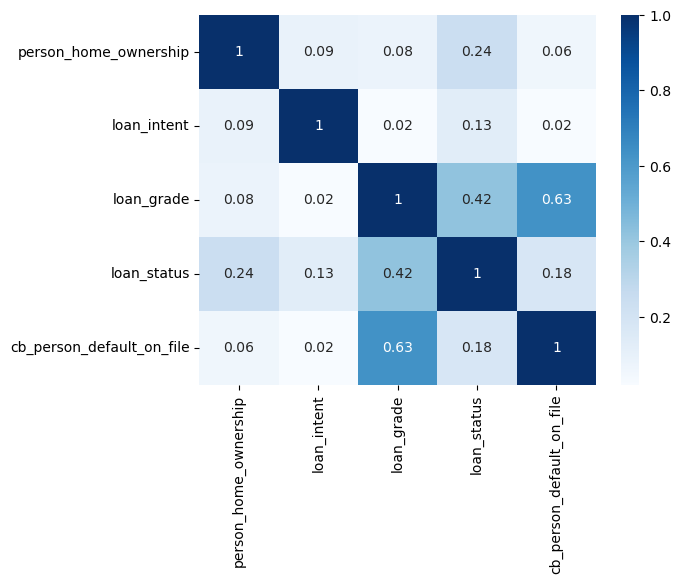

In [59]:
sns.heatmap(df_cramers , cmap="Blues", annot=True)
plt.show()

## 2:T-test

#### Loan interest rate vs Loan status

**Continuos vs. Categorical(2 level)**

**Summarization:**
Group by the categorical variable and compute summary statistics (mean, median, etc.) of the continuous variable

**Visualization:**

 Grouped Box Plot,
 Grouped Histogram

**Statistical Test:**
Independent Samples t-test 

**H0 (Null Hypothesis):**

There is no difference in mean loan interest rate between loan status groups.

**H1 (Alternative Hypothesis):**

There is a difference in mean loan interest rate between loan status groups.

#### Summarization

In [60]:
df1.groupby(['loan_status']).agg({'loan_int_rate':'mean'})

,loan_int_rate
loan_status,
0,10.466937
1,13.131180


In [63]:
df1.groupby(['loan_status']).agg({'loan_int_rate':'describe'})

loan_int_rate                                                  \
                    count       mean       std   min    25%    50%    75%   
loan_status                                                                 
0                 22313.0  10.466937  2.973871  5.42   7.74  10.62  12.69   
1                  6188.0  13.131180  3.260248  5.42  10.91  13.49  15.58   

                    
               max  
loan_status         
0            22.06  
1            23.22

#### Check Outliers

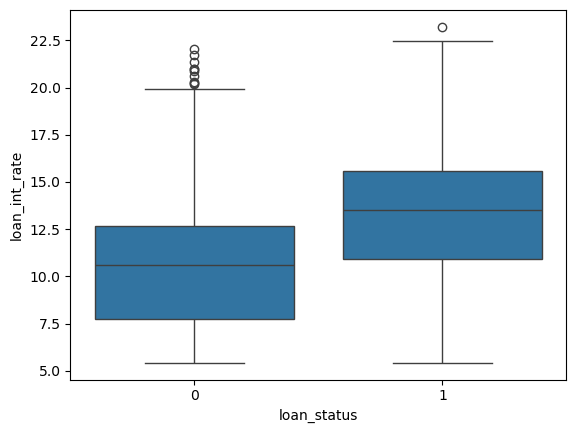

In [65]:
sns.boxplot(x='loan_status', y='loan_int_rate', data=df1)
plt.show()

In [68]:
Good_loan=df1[(df1['loan_status']==0)]
Bad_loan=df1[(df1['loan_status']==1)]
Good_loan.shape,Bad_loan.shape

((22313, 12), (6188, 12))

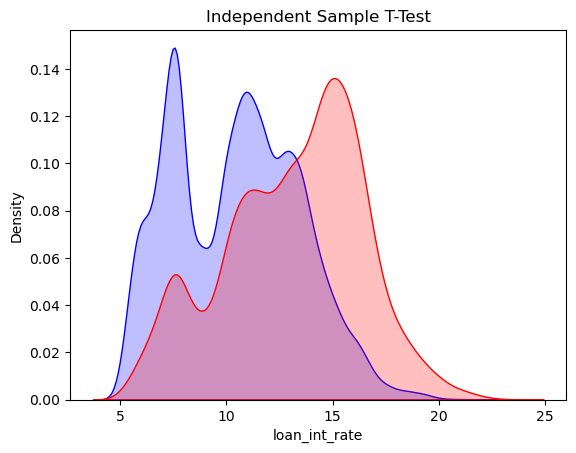

In [69]:
sns.kdeplot(Good_loan['loan_int_rate'], shade=True,color='blue')
sns.kdeplot(Bad_loan['loan_int_rate'], shade=True,color='red')
plt.title("Independent Sample T-Test")
plt.show()

#### Since the observation is a large sample,we can  rely on the Central Limit Theorem. 

#### Equality of variance

In [70]:
good=Good_loan['loan_int_rate']
bad=Bad_loan['loan_int_rate']

In [72]:
stats.levene(good,bad)

LeveneResult(statistic=np.float64(49.75086593655825), pvalue=np.float64(1.7854253833340425e-12))

#### Levene's test for equality of variances was significant(pvalue almost zero),indicating that the assumption of equality of variances was violated. Therefore,Welch's t-test was used to compare group means.

In [77]:
tStat, pValue = stats.ttest_ind(good, bad, equal_var = False)  
print(f"P-Value:{pValue} T-Statistic:{tStat}")
if pValue < 0.5:
    print('\n***There is a difference in mean loan interest rate between loan status groups.**')
else:
    print('There is no difference in mean loan interest rate between loan status groups.')

P-Value:0.0 T-Statistic:-57.94473089564104

***There is a difference in mean loan interest rate between loan status groups.**


#### Conclusion
     Loans that ended in default had higher interest than that were paid normally.

## 3: Anova

#### Home ownership vs Loan intereset rate

**Continuos vs. Categorical(4 level)**

**Summarization:**
Group by the categorical variable and compute summary statistics (mean, median, etc.) of the continuous variable

**Visualization:**

 Grouped Box Plot,
 Grouped Histogram

**Statistical Test:**
Independent Anova t-test 

**H0 (Null Hypothesis):**

There is no difference in mean loan interest rate between Home ownership groups.

**H1 (Alternative Hypothesis):**

There is a difference in mean loan interest rate between Home ownership groups.

#### Summarization

In [81]:
df1.groupby('person_home_ownership').agg({'loan_int_rate':'mean'})

,loan_int_rate
person_home_ownership,
MORTGAGE,10.532064
OTHER,12.028710
OWN,10.968648
RENT,11.466113


In [80]:
df1.groupby('person_home_ownership').agg({'loan_int_rate':'describe'})

loan_int_rate                                          \
                              count       mean       std   min   25%    50%   
person_home_ownership                                                         
MORTGAGE                    11736.0  10.532064  3.294324  5.42  7.51  10.59   
OTHER                          93.0  12.028710  2.638394  7.40  9.63  11.89   
OWN                          2174.0  10.968648  3.208238  5.42  7.90  11.10   
RENT                        14498.0  11.466113  3.122572  5.42  8.94  11.49   

                                     
                         75%    max  
person_home_ownership                
MORTGAGE               12.99  22.48  
OTHER                  14.26  17.90  
OWN                    13.43  21.27  
RENT                   13.61  23.22

#### checeking Outliers

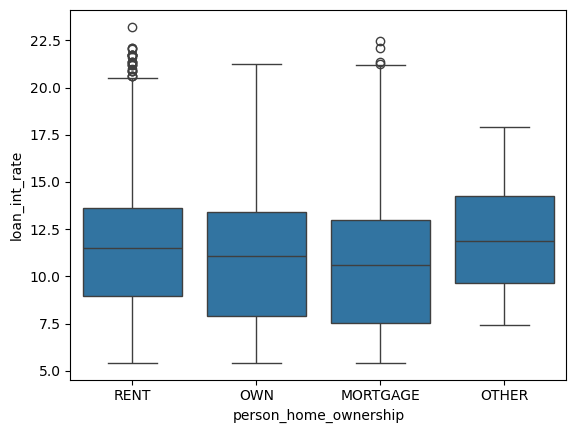

In [84]:
sns.boxplot(x='person_home_ownership', y='loan_int_rate', data=df1)
plt.show()

#### Normality test

Since we have a large number of observations, we can rely on the Central Limit Theorem (CLT) and assume that the sampling distribution is approximately normal.

#### Equality of variance

In [83]:
grp1=df1[df1['person_home_ownership']=='MORTGAGE']['loan_int_rate']
grp2=df1[df1['person_home_ownership']=='OWN']['loan_int_rate']
grp3=df1[df1['person_home_ownership']=='RENT']['loan_int_rate']
grp4=df1[df1['person_home_ownership']=='OTHER']['loan_int_rate']

In [85]:
stats.levene(grp1,grp2,grp3,grp4)

LeveneResult(statistic=np.float64(29.512384037512604), pvalue=np.float64(4.829152883828373e-19))

#### Levene's test for equality of variances was significant(pvalue almost zero),indicating that the assumption of equality of variances was violated. Therefore,Welch's t-test was used to compare group means.

In [92]:
welch=anova_oneway([grp1,grp2,grp3,grp4],use_var = 'unequal')
print(welch)

statistic = 186.33746864397145
pvalue = 2.5583918355145693e-78
df = (3.0, np.float64(446.1844944896911))
df_num = 3.0
df_denom = 446.1844944896911
nobs_t = 28501.0
n_groups = 4
means = [10.53206374 10.96864765 11.46611257 12.02870968]
nobs = [11736.  2174. 14498.    93.]
vars_ = [10.85257224 10.2927909   9.75045319  6.96112223]
use_var = unequal
welch_correction = True
tuple = (np.float64(186.33746864397145), np.float64(2.5583918355145693e-78))


pvalue is almost zero, we can say  There is a difference in mean loan interest rate between homw ownership groups.

Interest rates vary across home ownership categories.
Borrowers with a mortgage have the lowest average interest rates, while renters tend to face higher rates.
This suggests that home ownership status is associated with credit risk, with mortgage holders perceived as lower risk compared to renters.

#### Conclusion
      Mortgage holders receive the lowest interest rates.

### 4- Correlation 

In [34]:
corr1=df1.corr(numeric_only=True)
corr1

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.178987,0.165624,0.054246,0.010170,-0.040782,0.859621
person_income,0.178987,1.000000,0.136427,0.264942,-0.001346,-0.251487,0.116622
person_emp_length,0.165624,0.136427,1.000000,0.110934,-0.056607,-0.055033,0.146486
loan_amnt,0.054246,0.264942,0.110934,1.000000,0.146026,0.577708,0.045334
loan_int_rate,0.010170,-0.001346,-0.056607,0.146026,1.000000,0.123441,0.014562
loan_percent_income,-0.040782,-0.251487,-0.055033,0.577708,0.123441,1.000000,-0.029690
cb_person_cred_hist_length,0.859621,0.116622,0.146486,0.045334,0.014562,-0.029690,1.000000


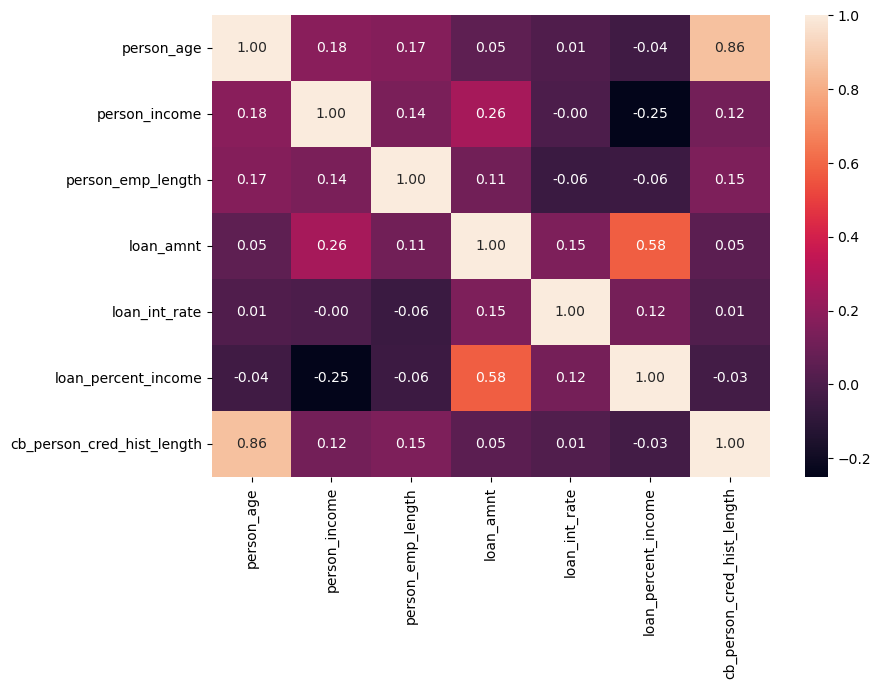

In [37]:
# Visualization 
plt.figure(figsize=(9,6))
sns.heatmap(corr1,annot=True,fmt='.2f')
plt.show()

## Collinearity / Multi-collinearity (VIF)

Age and credit history length showed strong correlation(0.86), indicating collinearity.
Since credit history length is more directly related to credit risk and interest rate determination, age can  removed from the regression model that are sensitive to collininearity to improve interpretability and coefficient stability.

In [103]:
# check multi-collinearity using VIF
# Drop target
X = df1.drop(columns=["loan_int_rate"])

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Drop rows with missing values
X = X.dropna()

# Add constant
X_const = add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

# Remove constant row
vif_data = vif_data[vif_data["Feature"] != "const"]

# Sort by highest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)


                      Feature       VIF
1                  person_age  3.944372
6  cb_person_cred_hist_length  3.856536
4                   loan_amnt  2.092009
5         loan_percent_income  2.064402
2               person_income  1.504108
3           person_emp_length  1.059239


# Part 2-Classification

# Import Data

In [5]:
df2=pd.read_csv("healthcare-dataset-stroke-data.csv") # for classification

# EDA (Exploratory Data Analysis)

In [6]:
# shape of data
df2.shape

(5110, 12)

In [7]:
# Brows Data Portion
# Head of data
df2.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [8]:
# tail of data
df2.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [9]:
#head and tail
df2

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### Stroke is the target

In [10]:
# Brows discriptor portion
##checking  number of obs and columns ,index of columns, name of columns, number of non_null values and datatype, (memory usage,...)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [11]:
# find number of missing values
df2.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [12]:
def inforamation2(df):
    df_information= pd.concat([df2.dtypes, df.isna().sum(),df.nunique()], axis=1, keys=['Data types','Number of Missing', 'Number of uique values'])
    return(df_information)

In [13]:
inforamation2(df2)

,Data types,Number of Missing,Number of uique values
id,int64,0,5110
gender,object,0,3
age,float64,0,104
hypertension,int64,0,2
heart_disease,int64,0,2
ever_married,object,0,2
work_type,object,0,5
Residence_type,object,0,2
avg_glucose_level,float64,0,3979
bmi,float64,201,418


## Descrptive Statistic

In [14]:
# get the summary of Data
# for only numeric columns
df2.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [15]:
# for all columns
df2.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [16]:
# To get mode( top) and number of levels for all columns
df2.astype('object').describe().T

,count,unique,top,freq
id,5110,5110,44679,1
gender,5110,3,Female,2994
age,5110.0,104.0,78.0,102.0
hypertension,5110,2,0,4612
heart_disease,5110,2,0,4834
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
avg_glucose_level,5110.0,3979.0,93.88,6.0
bmi,4909.0,418.0,28.7,41.0


In [17]:
#some columns are misclassified as int when they are an object
df2[['hypertension','heart_disease','stroke']]=df2[['hypertension','heart_disease','stroke']].astype('object')

In [18]:
df2.dtypes

id                     int64
gender                object
age                  float64
hypertension          object
heart_disease         object
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                object
dtype: object

In [19]:
#Drop insignificant column
df2=df2.drop('id',axis=1)

In [20]:
df2.shape

(5110, 11)

# Data Prepration

## Data Cleansing
1. Handling Duplicate Data
2. Handling Missing Values
3. Handling Outliers
4. Standardising Values
5. Fixing Invalid Values and Filter Data

### 1. Handling Duplicate Data

In [21]:
# Find number of duplicated rows
df2.duplicated().sum()

np.int64(0)

### 2. Handling Missing Values

In [22]:
#check missing values
df2.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [23]:
#calculatin no. of missing values for each column and it's percentage
def percentage_of_miss(df):
  df_m=df2[df2.columns[df2.isnull().sum()>=1]]# I get a subset of data that contain columns that have at least one missing values
  total_miss = df_m.isnull().sum().sort_values(ascending=False)
  percent_miss = (df_m.isnull().sum()/df2.shape[0]).sort_values(ascending=False)
  missing_data = pd.concat([total_miss, percent_miss], axis=1, keys=['Number of Missing', 'Percentage of Missing'])
  return(missing_data)

In [24]:
percentage_of_miss(df2)

,Number of Missing,Percentage of Missing
bmi,201,0.039335


In [25]:
#since the number of observation for the missing value compared to the dataset  is too small ,I will remove those observation
df2.dropna(subset=['bmi'],inplace=True)

In [26]:
df2.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

## UNIVARIATE  ANALYSIS

In [27]:
# get all categorical columns:
df2_cat=df2.select_dtypes(include='object')
df2_cat.columns

Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status', 'stroke'],
      dtype='object')

In [28]:
# get all numerical columns:
df2_num=df2.select_dtypes(exclude='object')
df2_num.columns

Index(['age', 'avg_glucose_level', 'bmi'], dtype='object')

In [29]:
# Find the frequency of each levels in all categorcal columns
for c in df2_cat.columns:
    print(df2[c].value_counts())
    print("="*30)

gender
Female    2897
Male      2011
Other        1
Name: count, dtype: int64
hypertension
0    4458
1     451
Name: count, dtype: int64
heart_disease
0    4666
1     243
Name: count, dtype: int64
ever_married
Yes    3204
No     1705
Name: count, dtype: int64
work_type
Private          2811
Self-employed     775
children          671
Govt_job          630
Never_worked       22
Name: count, dtype: int64
Residence_type
Urban    2490
Rural    2419
Name: count, dtype: int64
smoking_status
never smoked       1852
Unknown            1483
formerly smoked     837
smokes              737
Name: count, dtype: int64
stroke
0    4700
1     209
Name: count, dtype: int64


### Visualization

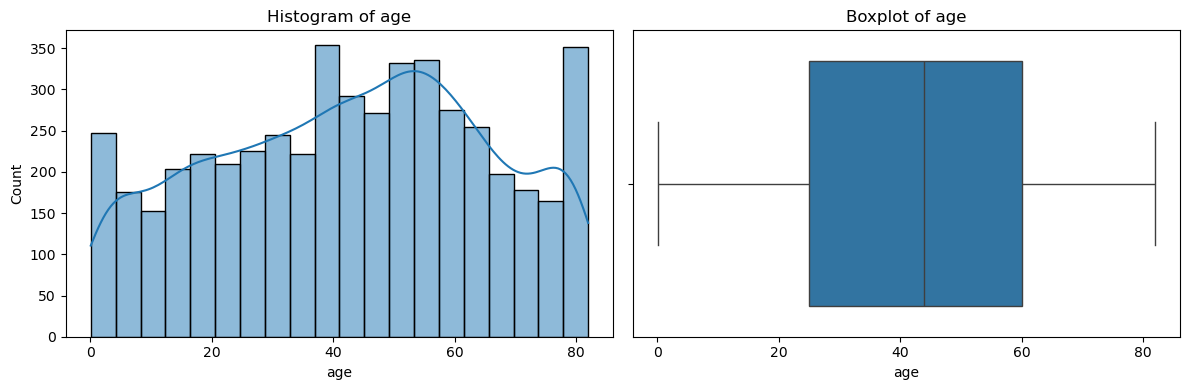

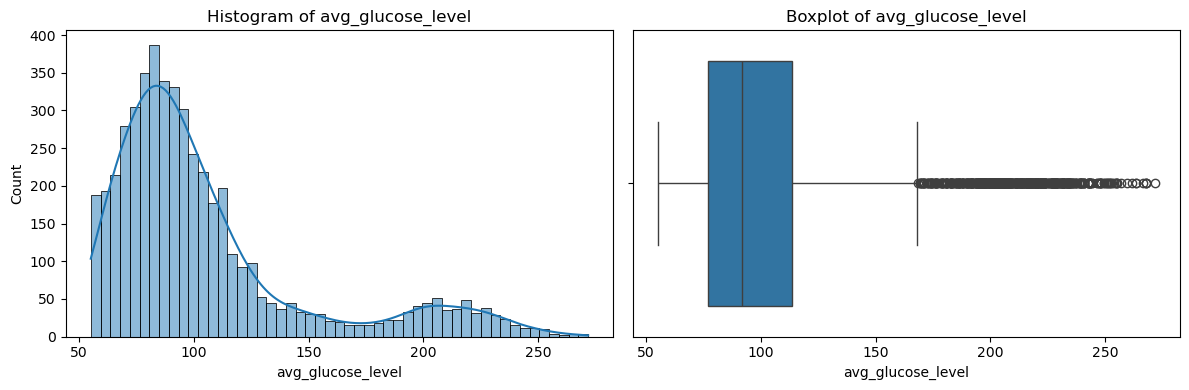

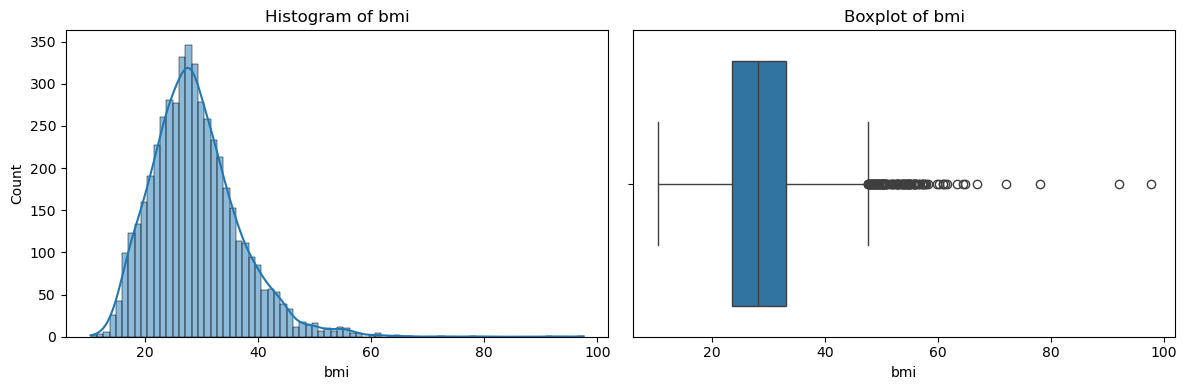

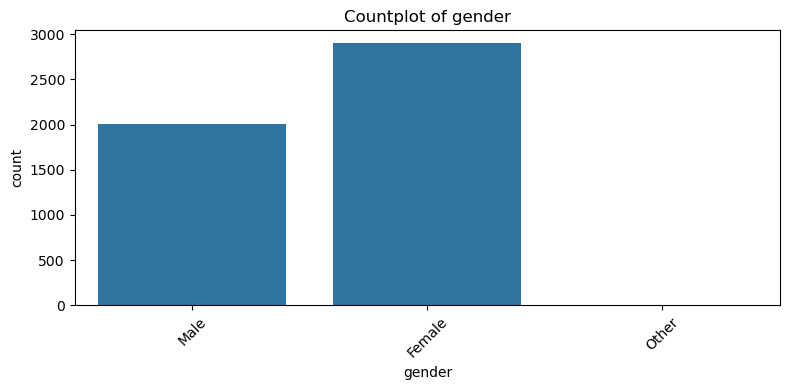

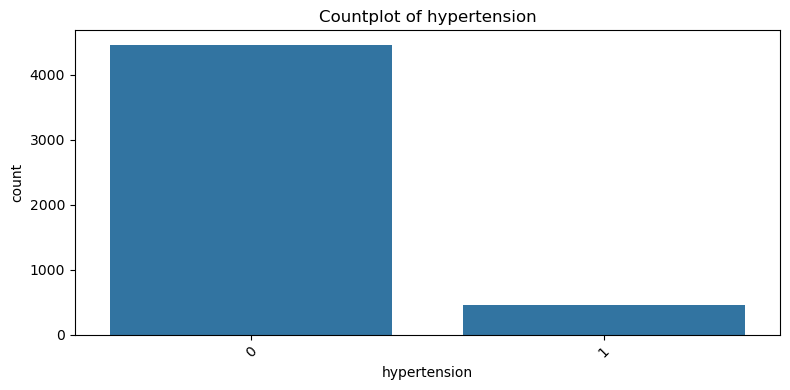

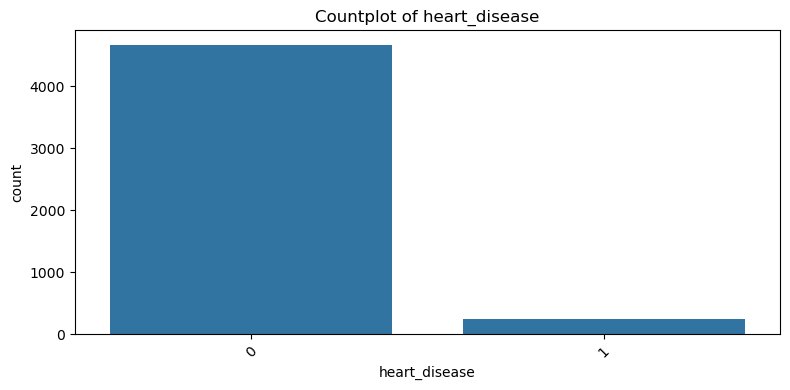

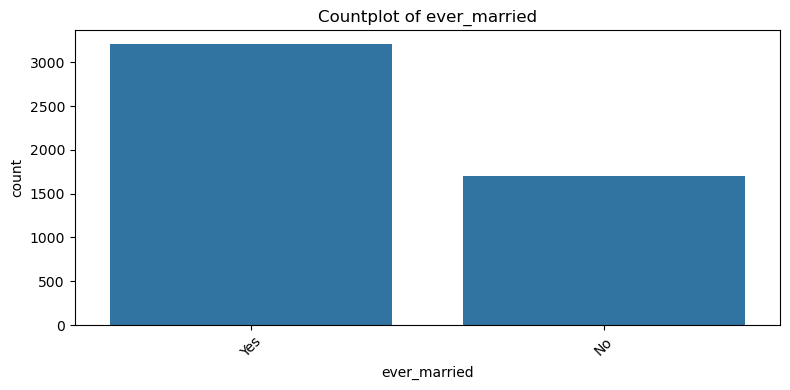

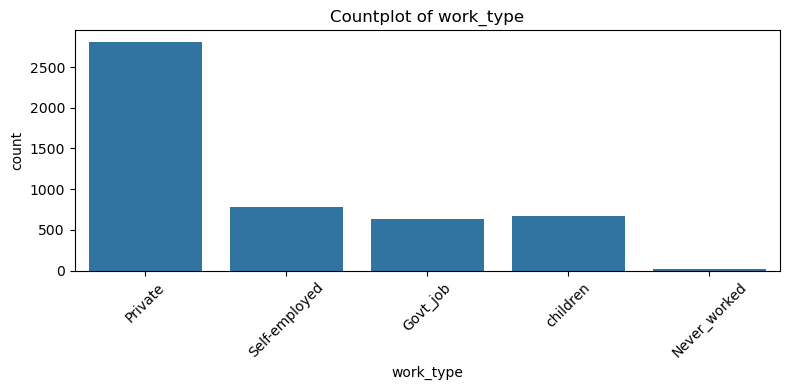

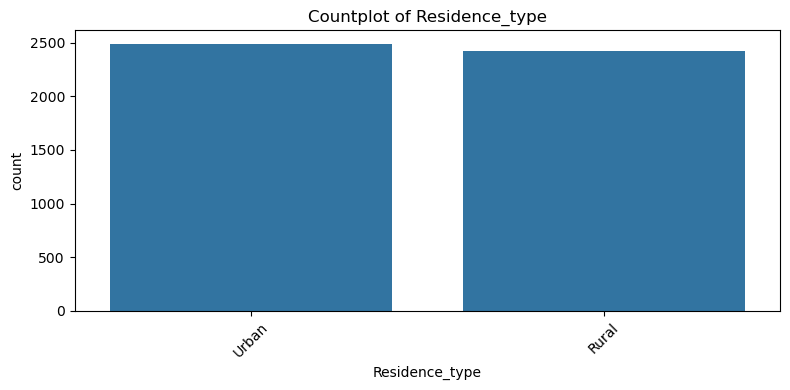

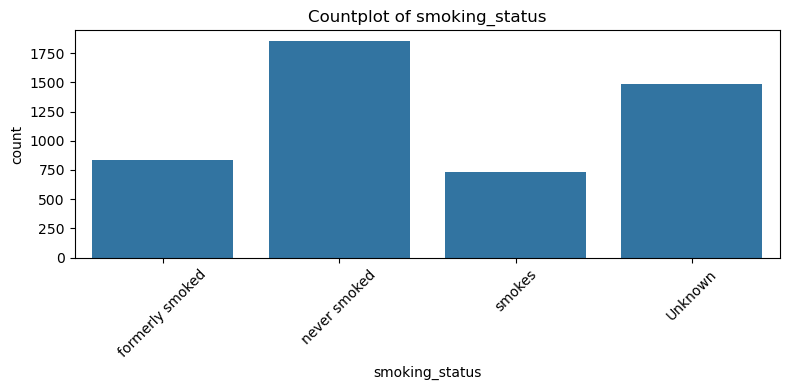

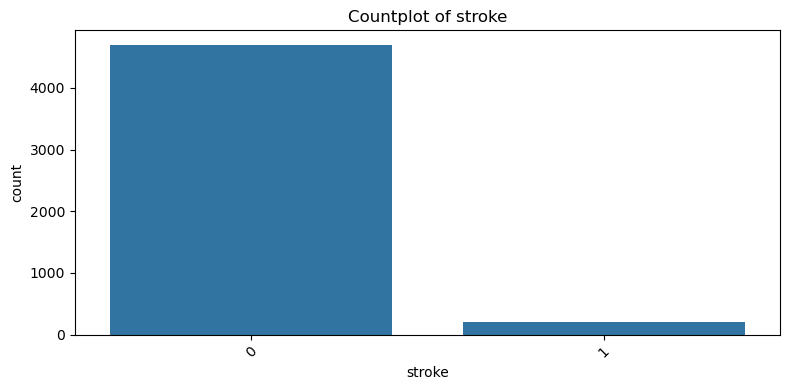

In [30]:
# --- Numeric variables: histograms & boxplots ---
for col in df2_num.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df2[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {col}")
    
    # Boxplot
    sns.boxplot(x=df2[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()

# --- Categorical variables: countplots ---
for col in  df2_cat.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df2, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Target: Stroke

In [31]:
df2['stroke'].value_counts()

stroke
0    4700
1     209
Name: count, dtype: int64

In [32]:
df2.stroke.value_counts(normalize=True)

stroke
0    0.957425
1    0.042575
Name: proportion, dtype: float64

#### The target variable is highly imbalanced

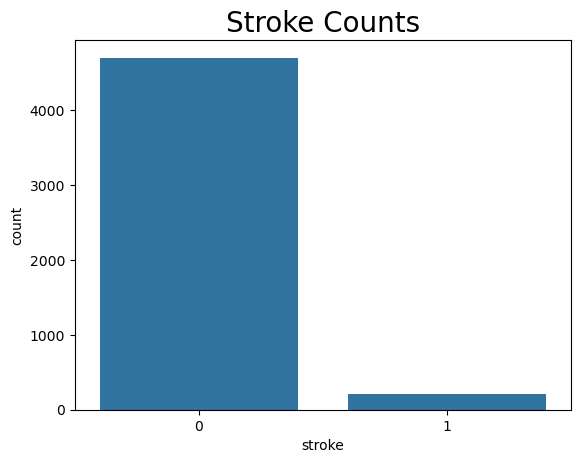

In [33]:
#countplot
sns.countplot(x=df2.stroke)
plt.title("Stroke Counts", y=1, fontdict={"fontsize": 20})
# Show the plot
plt.show()

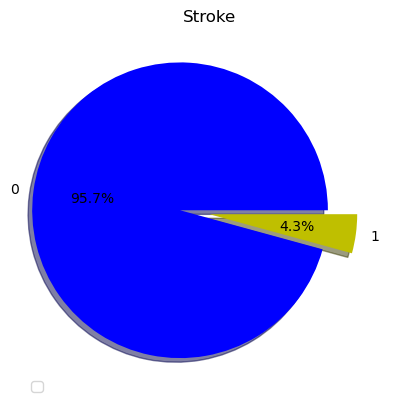

In [34]:
##Pie chart
Loan_Status=df2['stroke'].value_counts()
values = [Loan_Status[0],Loan_Status[1]]
colors = ['b', 'y']
labels = ['0','1']
explode = (0.2, 0)
plt.title('Stroke')
plt.legend(labels,loc=3)
plt.pie(values, colors=colors, labels=labels,
explode=explode, autopct='%1.1f%%', counterclock=True, shadow=True)

plt.show()

### 3 Detecting outliers


In [35]:
def outlier_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    count = outliers.shape[0]

    print(f"Lower bound: {lower}")
    print(f"Upper bound: {upper}")
    print(f"Outliers detected in '{column}': {count}")

    return outliers

In [36]:
# check outliers for age
result_age = outlier_iqr(df2, "age")

Lower bound: -27.5
Upper bound: 112.5
Outliers detected in 'age': 0


In [37]:
df2.age.describe()

count    4909.000000
mean       42.865374
std        22.555115
min         0.080000
25%        25.000000
50%        44.000000
75%        60.000000
max        82.000000
Name: age, dtype: float64

      There is no Outlier detected in column age 
      

In [38]:
# check outliers for glucose level
result_avg= outlier_iqr(df2, "avg_glucose_level")

Lower bound: 22.319999999999993
Upper bound: 168.32
Outliers detected in 'avg_glucose_level': 567


In [39]:
df2.avg_glucose_level.describe()

count    4909.000000
mean      105.305150
std        44.424341
min        55.120000
25%        77.070000
50%        91.680000
75%       113.570000
max       271.740000
Name: avg_glucose_level, dtype: float64

In [40]:
df2.avg_glucose_level.quantile([0,0.01,0.50,0.70,0.90,0.95,0.99,1]) 

0.00     55.1200
0.01     56.3208
0.50     91.6800
0.70    108.0300
0.90    187.0040
0.95    214.6420
0.99    240.5500
1.00    271.7400
Name: avg_glucose_level, dtype: float64

Although the upper values appear as statistical outliers based on the IQR rule, they are clinically reasonable glucose levels and may represent patients with severe hyperglycemia. Therefore, they should not be removed without further medical justification.

In [41]:
# check outliers for bmi
result_age = outlier_iqr(df2, "bmi")

Lower bound: 9.099999999999998
Upper bound: 47.5
Outliers detected in 'bmi': 110


In [42]:
df2.bmi.describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [43]:
df2.bmi.quantile([0,0.01,0.50,0.70,0.90,0.95,0.99,1]) 

0.00    10.30
0.01    15.10
0.50    28.10
0.70    31.90
0.90    38.90
0.95    42.96
0.99    53.40
1.00    97.60
Name: bmi, dtype: float64

Although most BMI values fall within clinically realistic ranges, the maximum value (97.6) appears to be an extreme outlier and may result from data entry error. Therefore, it should be further investigated before modeling.

In [44]:
df2[df2['bmi'] > 60]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
270,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
358,Male,52.0,0,0,Yes,Self-employed,Urban,78.40,64.8,never smoked,0
466,Female,61.0,1,0,Yes,Private,Rural,170.05,60.2,smokes,0
544,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0
928,Female,23.0,1,0,No,Private,Urban,70.03,78.0,smokes,0
1559,Female,53.0,0,0,Yes,Private,Rural,72.63,66.8,Unknown,0
2128,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0
2764,Female,24.0,0,0,Yes,Private,Urban,85.55,63.3,never smoked,0
2840,Female,52.0,0,0,Yes,Private,Urban,98.27,61.2,Unknown,0
3825,Female,52.0,0,0,Yes,Private,Rural,118.46,61.6,smokes,0


A small number of observations exhibited extremely high BMI values (>60).
These were retained as valid extreme cases rather than removed, as no evidence of data-entry errors was found.

In [45]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4909 non-null   object 
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   object 
 3   heart_disease      4909 non-null   object 
 4   ever_married       4909 non-null   object 
 5   work_type          4909 non-null   object 
 6   Residence_type     4909 non-null   object 
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   object 
 10  stroke             4909 non-null   object 
dtypes: float64(3), object(8)
memory usage: 460.2+ KB


## Bivariate Analysis

### 1: Chi Square Test

**Categorical vs. Categorical**

**Summarization:**
Contingency Table (two-way frequency table)

**Visualization:**
Stacked Bar Chart
 Grouped Bar Chart

**Statistical Test:**
Chi-Square Test of Independence

**H0 (Null Hypothesis):**

There is no association between two Variables(They are statistically independent.)

**H1 (Alternative Hypothesis):**

There is an association between the Variables((They are not independent.)

#### 1 Gender vs Stroke

In [46]:
df2.stroke.value_counts()

stroke
0    4700
1     209
Name: count, dtype: int64

In [47]:
df2.gender.value_counts()

gender
Female    2897
Male      2011
Other        1
Name: count, dtype: int64

Due to the presence of a gender category with only one observation, the chi-square test assumptions were violated.
The category was removed to ensure valid expected frequencies before conducting the test.

In [48]:
df_chi = df2[df2['gender'] != 'Other']

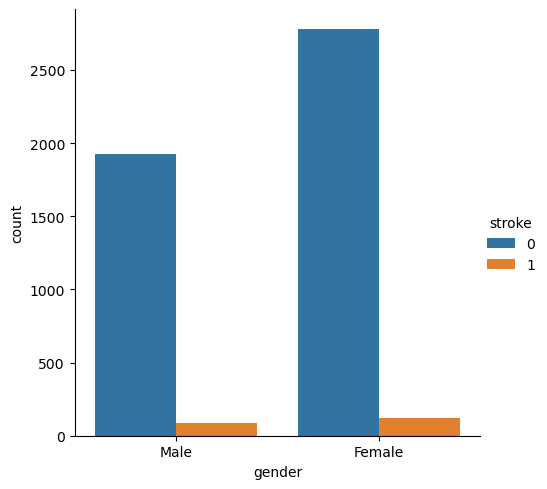

In [49]:
sns.catplot(x='gender', kind="count",hue = 'stroke', data=df_chi)
plt.show()

In [50]:
contingency_table2 = pd.crosstab(df_chi['gender'],df_chi['stroke'])
contingency_table2

stroke,0,1
gender,,
Female,2777,120
Male,1922,89


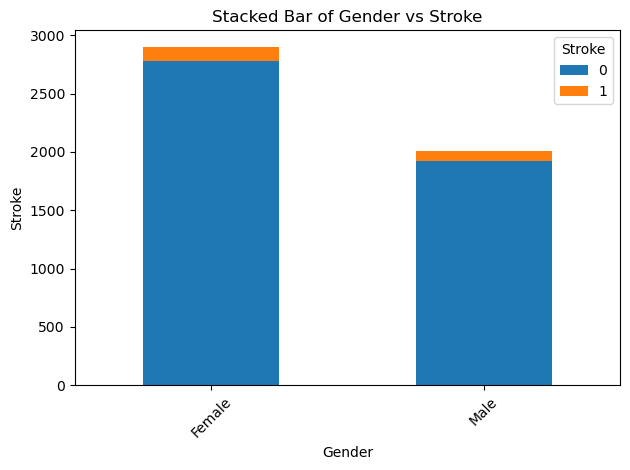

In [51]:
# Visualization Stacked bar
contingency_table2.plot(kind='bar', stacked=True)

plt.title(f"Stacked Bar of Gender vs Stroke")
plt.xlabel('Gender')
plt.ylabel("Stroke")
plt.xticks(rotation=45)
plt.legend(title='Stroke', loc='upper right')
plt.tight_layout()
plt.show()

In [52]:
chi2, p, dof, expected = chi2_contingency(contingency_table2)

print("\nChi-square test:  Gender  vs Stroke")
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)

print("\np-value:", p)
if p < 0.05:
    print('**There is statistiacally significant correlation between Gender  and Stroke at 0.05 significant level**')
else:
    print("***There is no association between the two variables***")


Chi-square test:  Gender  vs Stroke
Chi-square statistic: 0.16955129804441268
Degrees of freedom: 1

Expected counts:
[[2773.63549307  123.36450693]
 [1925.36450693   85.63549307]]

p-value: 0.6805108914997836
***There is no association between the two variables***


#### 2 Heart_Disease   vs Stroke

In [53]:
df2.heart_disease.value_counts()

heart_disease
0    4666
1     243
Name: count, dtype: int64

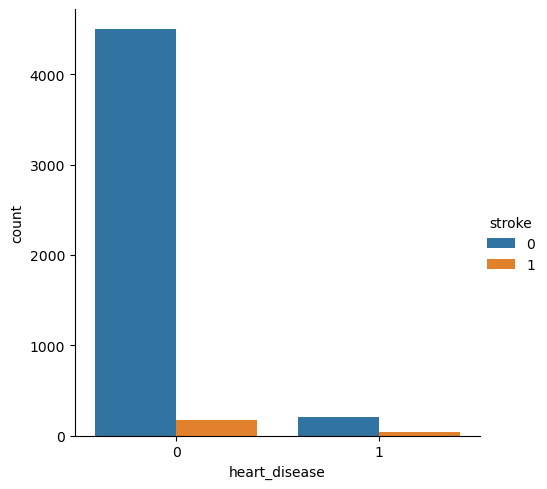

In [54]:
sns.catplot(x='heart_disease', kind="count",hue = 'stroke', data=df2)
plt.show()

In [55]:
contingency_table3 = pd.crosstab(df2['heart_disease'],df2['stroke'])
contingency_table3

stroke,0,1
heart_disease,,
0,4497,169
1,203,40


In [56]:
chi2, p, dof, expected = chi2_contingency(contingency_table3)

print("\nChi-square test:  Heart_disaese vs Stroke")
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)

print("\np-value:", p)
if p < 0.05:
    print('**There is statistiacally significant correlation between Heart Disease and Stroke at 0.05 significant level**')
else:
    print("***There is no association between the two variables***")


Chi-square test:  Heart_disaese vs Stroke
Chi-square statistic: 90.2795595563918
Degrees of freedom: 1

Expected counts:
[[4467.34569159  198.65430841]
 [ 232.65430841   10.34569159]]

p-value: 2.0677783295228626e-21
**There is statistiacally significant correlation between Heart Disease and Stroke at 0.05 significant level**


#### Conclusion 
      People who have have heart disease are at high risk of getting a stroke.

#### 3 Hypertension vs Stroke

In [57]:
df2.hypertension.value_counts()

hypertension
0    4458
1     451
Name: count, dtype: int64

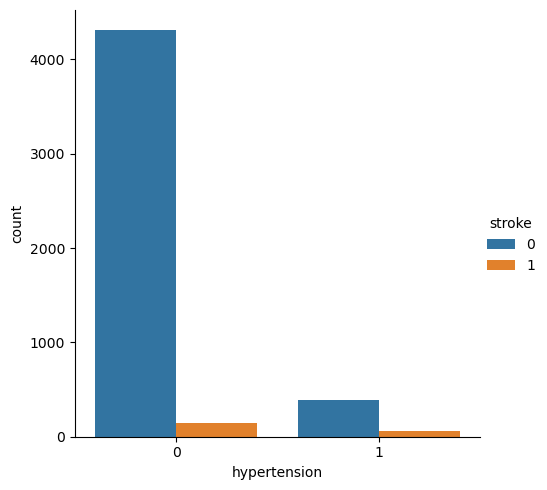

In [58]:
sns.catplot(x='hypertension', kind="count",hue = 'stroke', data=df2)
plt.show()

In [59]:
contingency_table4 = pd.crosstab(df2['hypertension'],df2['stroke'])
contingency_table4

stroke,0,1
hypertension,,
0,4309,149
1,391,60


In [60]:
chi2, p, dof, expected = chi2_contingency(contingency_table4)

print("\nChi-square test:  Hypertension vs Stroke")
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)

print("\np-value:", p)
if p < 0.05:
    print('**There is statistiacally significant correlation between Hypertension and Stroke at 0.05 significant level**')
else:
    print("***There is no association between the two variables***")


Chi-square test:  Hypertension vs Stroke
Chi-square statistic: 97.2749949311716
Degrees of freedom: 1

Expected counts:
[[4268.20126299  189.79873701]
 [ 431.79873701   19.20126299]]

p-value: 6.033751208728256e-23
**There is statistiacally significant correlation between Hypertension and Stroke at 0.05 significant level**


#### Conclusion 
      People who have hypertension are at high risk of getting a stroke.

#### 4 Smoking status vs Stroke

In [61]:
df2.smoking_status.value_counts()

smoking_status
never smoked       1852
Unknown            1483
formerly smoked     837
smokes              737
Name: count, dtype: int64

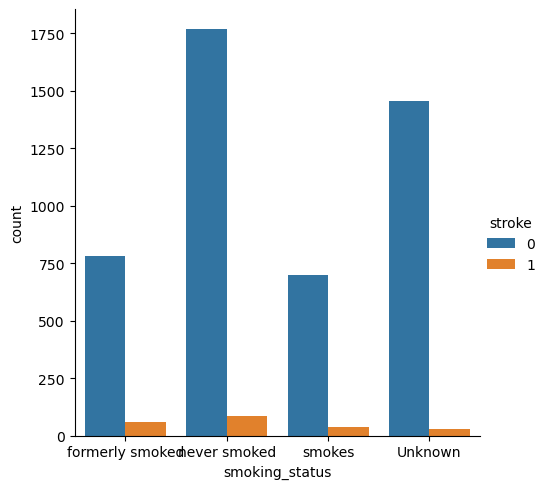

In [62]:
sns.catplot(x='smoking_status', kind="count",hue = 'stroke', data=df2)
plt.show()

In [63]:
contingency_table5 = pd.crosstab(df2['smoking_status'],df2['stroke'])
contingency_table5

stroke,0,1
smoking_status,,
Unknown,1454,29
formerly smoked,780,57
never smoked,1768,84
smokes,698,39


In [64]:
chi2, p, dof, expected = chi2_contingency(contingency_table5)

print("\nChi-square test:  Smoking status vs Stroke")
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("\nExpected counts:")
print(expected)

print("\np-value:", p)
if p < 0.05:
    print('**There is statistiacally significant correlation between Smoking status and Stroke at 0.05 significant level**')
else:
    print("***There is no association between the two variables***")


Chi-square test:  Smoking status vs Stroke
Chi-square statistic: 34.9434924570628
Degrees of freedom: 3

Expected counts:
[[1419.86147892   63.13852108]
 [ 801.36484009   35.63515991]
 [1773.15135465   78.84864535]
 [ 705.62232634   31.37767366]]

p-value: 1.2522021032753853e-07
**There is statistiacally significant correlation between Smoking status and Stroke at 0.05 significant level**


#### Conclusion 
      People who have a history of smoking  are at high risk of getting a stroke.

## Cramer's V

In [65]:
def cramers_V(var1,var2) :
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None)) 
  stat = chi2_contingency(crosstab)[0] 
  obs = np.sum(crosstab)
  mini = min(crosstab.shape)-1
  return np.sqrt((stat/(obs*mini)))

In [66]:
cramers_V(df2['heart_disease'],df2['stroke'])

np.float64(0.1356120246048841)

#### The strength of the association between Herat disease and Stroke is weak.

In [67]:
df2_cat.columns

Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status', 'stroke'],
      dtype='object')

In [68]:
rows= []

for var1 in df2_cat.columns:
  col = []
  for var2 in df2_cat.columns: 
    cramers =cramers_V(df2[var1], df2[var2]) # Cramer's V test
    col.append(round(cramers,2)) # Keeping of the rounded value of the Cramer's V  
  rows.append(col)
  
cramers = np.array(rows)
df_cramers2= pd.DataFrame(cramers, columns = df2_cat.columns, index =df2_cat.columns)

In [69]:
df_cramers2

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke
gender,1.00,0.02,0.08,0.04,0.07,0.02,0.07,0.01
hypertension,0.02,1.00,0.11,0.16,0.16,0.00,0.14,0.14
heart_disease,0.08,0.11,1.00,0.11,0.11,0.00,0.10,0.14
ever_married,0.04,0.16,0.11,1.00,0.57,0.00,0.35,0.10
work_type,0.07,0.16,0.11,0.57,1.00,0.03,0.30,0.09
Residence_type,0.02,0.00,0.00,0.00,0.03,1.00,0.03,0.01
smoking_status,0.07,0.14,0.10,0.35,0.30,0.03,1.00,0.08
stroke,0.01,0.14,0.14,0.10,0.09,0.01,0.08,1.00


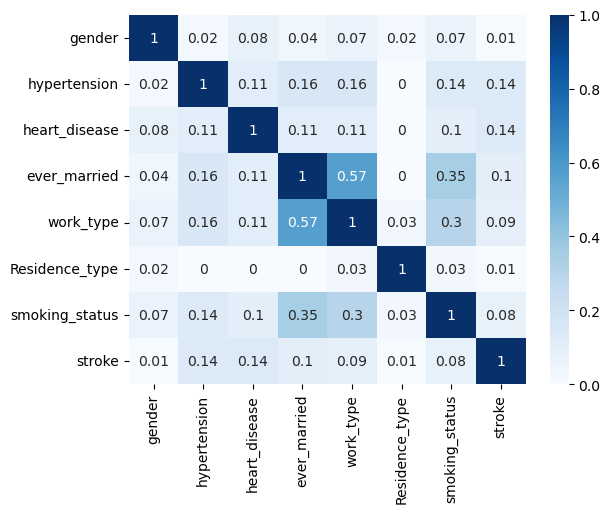

In [70]:
sns.heatmap(df_cramers2 , cmap="Blues", annot=True)
plt.show()

## 2:T-test

#### BMI Vs Stroke

**Continuos vs. Categorical(2 level)**

**Summarization:**
Group by the categorical variable and compute summary statistics (mean, median, etc.) of the continuous variable

**Visualization:**

 Grouped Box Plot,
 Grouped Histogram

**Statistical Test:**
Independent Samples t-test 

**H0 (Null Hypothesis):**

There is no difference in mean bmi between stroke groups.

**H1 (Alternative Hypothesis):**

There is a difference in mean bmi between stroke groups.

#### Summarization

In [71]:
df2.groupby(['stroke']).agg({'bmi':'mean'})

,bmi
stroke,
0,28.823064
1,30.471292


In [72]:
df2.groupby(['stroke']).agg({'bmi':'describe'})

bmi                                                   
         count       mean       std   min   25%   50%   75%   max
stroke                                                           
0       4700.0  28.823064  7.908287  10.3  23.4  28.0  33.1  97.6
1        209.0  30.471292  6.329452  16.9  26.4  29.7  33.7  56.6

#### Check Outliers

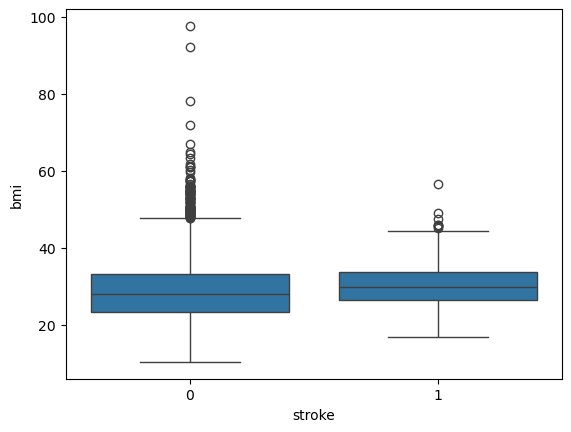

In [73]:
sns.boxplot(x='stroke', y='bmi', data=df2)
plt.show()

In [74]:
No=df2[(df2['stroke']==0)]
Yes=df2[(df2['stroke']==1)]
No.shape,Yes.shape

((4700, 11), (209, 11))

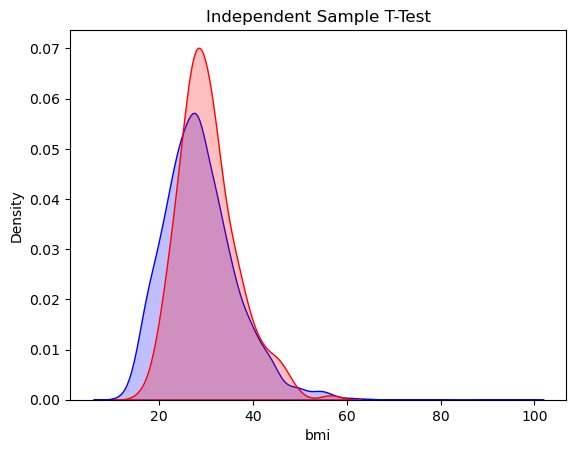

In [75]:
sns.kdeplot(No['bmi'], shade=True,color='blue')
sns.kdeplot(Yes['bmi'], shade=True,color='red')
plt.title("Independent Sample T-Test")
plt.show()

#### Since the observation is a large sample,we can  rely on the Central Limit Theorem. 

#### Equality of variance

In [76]:
yes=Yes['bmi']
no=No['bmi']

In [77]:
stats.levene(yes,no)

LeveneResult(statistic=np.float64(10.424906294692374), pvalue=np.float64(0.0012514571727516878))

#### Levene's test for equality of variances was significant(pvalue almost zero),indicating that the assumption of equality of variances was violated. Therefore,Welch's t-test was used to compare group means.

In [78]:
tStat, pValue = stats.ttest_ind(yes, no, equal_var = False)  
print(f"P-Value:{pValue} T-Statistic:{tStat}")
if pValue < 0.5:
    print('\n***There is a difference in bmi between stroke groups.**')
else:
    print('There is no difference in mean bmi between Stroke groups.')

P-Value:0.0003339710013121601 T-Statistic:3.6404100561556993

***There is a difference in bmi between stroke groups.**


#### Conclusion
     People who have had a stroke tend to have a higher BMI compared to those who have not experienced a stroke.

## 3: Anova

#### Smoking_status vs Ave_glucose_level

**Continuos vs. Categorical(4 level)**

**Summarization:**
Group by the categorical variable and compute summary statistics (mean, median, etc.) of the continuous variable

**Visualization:**

 Grouped Box Plot,
 Grouped Histogram

**Statistical Test:**
Independent Anova t-test 

**H0 (Null Hypothesis):**

There is no difference in mean Average glucose level among smoking status groups.

**H1 (Alternative Hypothesis):**

There is a difference in  mean Average glucose level among smoking status groups.

#### Summarization

In [79]:
df2.groupby('smoking_status').agg({'avg_glucose_level':'mean'})

,avg_glucose_level
smoking_status,
Unknown,98.335927
formerly smoked,112.579821
never smoked,107.136215
smokes,106.465699


In [80]:
df2.groupby('smoking_status').agg({'avg_glucose_level':'describe'})

avg_glucose_level                                         \
                            count        mean        std    min      25%   
smoking_status                                                             
Unknown                    1483.0   98.335927  34.742280  55.23  76.7400   
formerly smoked             837.0  112.579821  51.791000  55.27  78.2800   
never smoked               1852.0  107.136215  46.344071  55.12  76.9875   
smokes                      737.0  106.465699  45.976285  55.32  76.3400   

                                           
                    50%       75%     max  
smoking_status                             
Unknown          90.070  109.5150  254.60  
formerly smoked  92.590  120.0300  267.76  
never smoked     92.135  115.9825  267.60  
smokes           93.580  114.3200  271.74

#### checeking Outliers

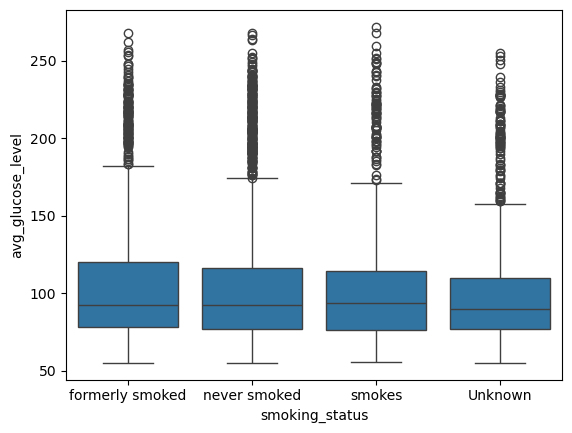

In [81]:
sns.boxplot(x='smoking_status', y='avg_glucose_level', data=df2)
plt.show()

#### Normality test

Since we have a large number of observations, we can rely on the Central Limit Theorem (CLT) and assume that the sampling distribution is approximately normal.

In [82]:
grp1=df2[df2['smoking_status']=='formerly smoked']['avg_glucose_level']
grp2=df2[df2['smoking_status']=='never smoked']['avg_glucose_level']
grp3=df2[df2['smoking_status']=='smokes']['avg_glucose_level']
grp4=df2[df2['smoking_status']=='Unknown']['avg_glucose_level']

In [83]:
print(len(grp1), len(grp2), len(grp3), len(grp4))

837 1852 737 1483


In [84]:
stats.levene(grp1,grp2,grp3,grp4)

LeveneResult(statistic=np.float64(25.615679867248186), pvalue=np.float64(1.9464100046185736e-16))

#### Conclusion:
          The assumption of homogeneity of variances is violated.

### Levene’s test was significant (p < 0.05), indicating that the assumption of equal variances was violated. Therefore, Welch’s ANOVA was used instead of the standard one-way ANOVA.

In [85]:
from statsmodels.stats.oneway import anova_oneway

In [86]:
welch=anova_oneway([grp1,grp2,grp3,grp4],use_var = 'unequal')
print(welch)

statistic = 24.251345721277826
pvalue = 2.026356832522332e-15
df = (3.0, np.float64(2050.978258909059))
df_num = 3.0
df_denom = 2050.978258909059
nobs_t = 4909.0
n_groups = 4
means = [112.57982079 107.1362149  106.46569878  98.33592717]
nobs = [ 837. 1852.  737. 1483.]
vars_ = [2682.30771827 2147.77287691 2113.81877455 1207.02600891]
use_var = unequal
welch_correction = True
tuple = (np.float64(24.251345721277826), np.float64(2.026356832522332e-15))


pvalue is almost zero,There is a statistically significant difference in average glucose levels among the smoking groups.

#### conclusion
            Individuals who formerly smoked have the highest average glucose level compared to the other groups.

### 4-Correlation

In [87]:
corr2=df2.corr(numeric_only=True)
corr2

,age,avg_glucose_level,bmi
age,1.000000,0.235838,0.333398
avg_glucose_level,0.235838,1.000000,0.175502
bmi,0.333398,0.175502,1.000000


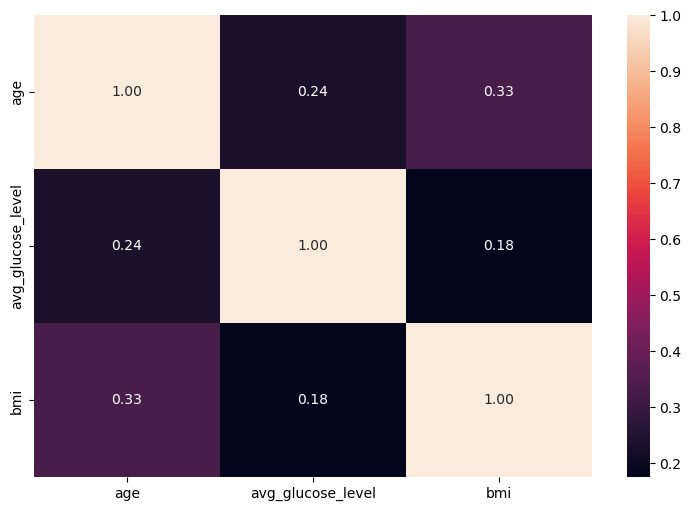

In [88]:
# Visualization 
plt.figure(figsize=(9,6))
sns.heatmap(corr2,annot=True,fmt='.2f')
plt.show()